# Advanced KNN

We implement the KNN in two rounds. 
- Round 1: select the 20 closest neighbors of the liked songs centroid based on only audio features
- Round 2: select from the 20 neighbors the closest in the same gerne as teh previous liked song (if available)


In the recommender logic we will build a pipeline that first selects the 20 closest neighbor to the liked songs centroid. This part of the pipeline will be tested by seeing how many of the 20 songs actually correspond to the same genre as the history of liked songs.
In the second round from the 20 neighbors we select the closest from teh same genre as teh lst song if available, if not then the closest one regardless of genre. We test this part of the pipeline by the rank of the closest same genre song has.

In [34]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.feature_selection import VarianceThreshold
import seaborn as sns
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

In [35]:
import sys
import os
import logging
from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Add project root to path for imports
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Load environment and config (force refresh)
load_dotenv(project_root / '.env', override=True)
from soeSpotify import config

# Styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
palette = sns.color_palette("viridis", as_cmap=False)

print("Setup complete.")

Setup complete.


In [36]:
print("Loading analytical datasets...")

# We use the analytics stage data as it is already cleaned and joined
df_tracks = pd.read_parquet(config.ANALYTICS_TRACKS)
df_artists = pd.read_parquet(config.ANALYTICS_ARTISTS)
df_genres = pd.read_parquet(config.ANALYTICS_GENRES)
df_features = pd.read_parquet(config.ANALYTICS_TRACK_FEATURES)

print(f"Tracks loaded:   {len(df_tracks):,}")
print(f"Artists loaded:  {len(df_artists):,}")
print(f"Genres loaded:   {len(df_genres):,}")
print(f"Features loaded: {len(df_features):,}")

Loading analytical datasets...
Tracks loaded:   101,144
Artists loaded:  56,129
Genres loaded:   87,202
Features loaded: 101,144


In [37]:
# display how many song are in each release decade that needs to be derived from the release_date for each artist_primary_genre_broad



release_decade,1880s,1920s,1930s,1940s,1950s,1960s,1970s,1980s,1990s,2000s,2010s
artist_primary_genre_broad,,,,,,,,,,,
,0,0,0,0,48,103,68,26,24,411,1494
blues,0,3,9,3,14,64,198,207,322,603,1734
classical,0,0,0,3,30,58,90,271,963,2000,7792
electronic,0,0,1,0,0,1,3,24,132,226,3479
folk,0,0,0,2,27,68,107,47,146,310,1579
hip hop,0,0,0,0,2,35,142,236,726,1331,11497
house,0,0,0,1,5,90,28,47,138,964,6901
indie,1,0,1,3,33,80,110,90,210,739,8165
jazz,0,1,0,1,6,11,59,76,182,488,2710


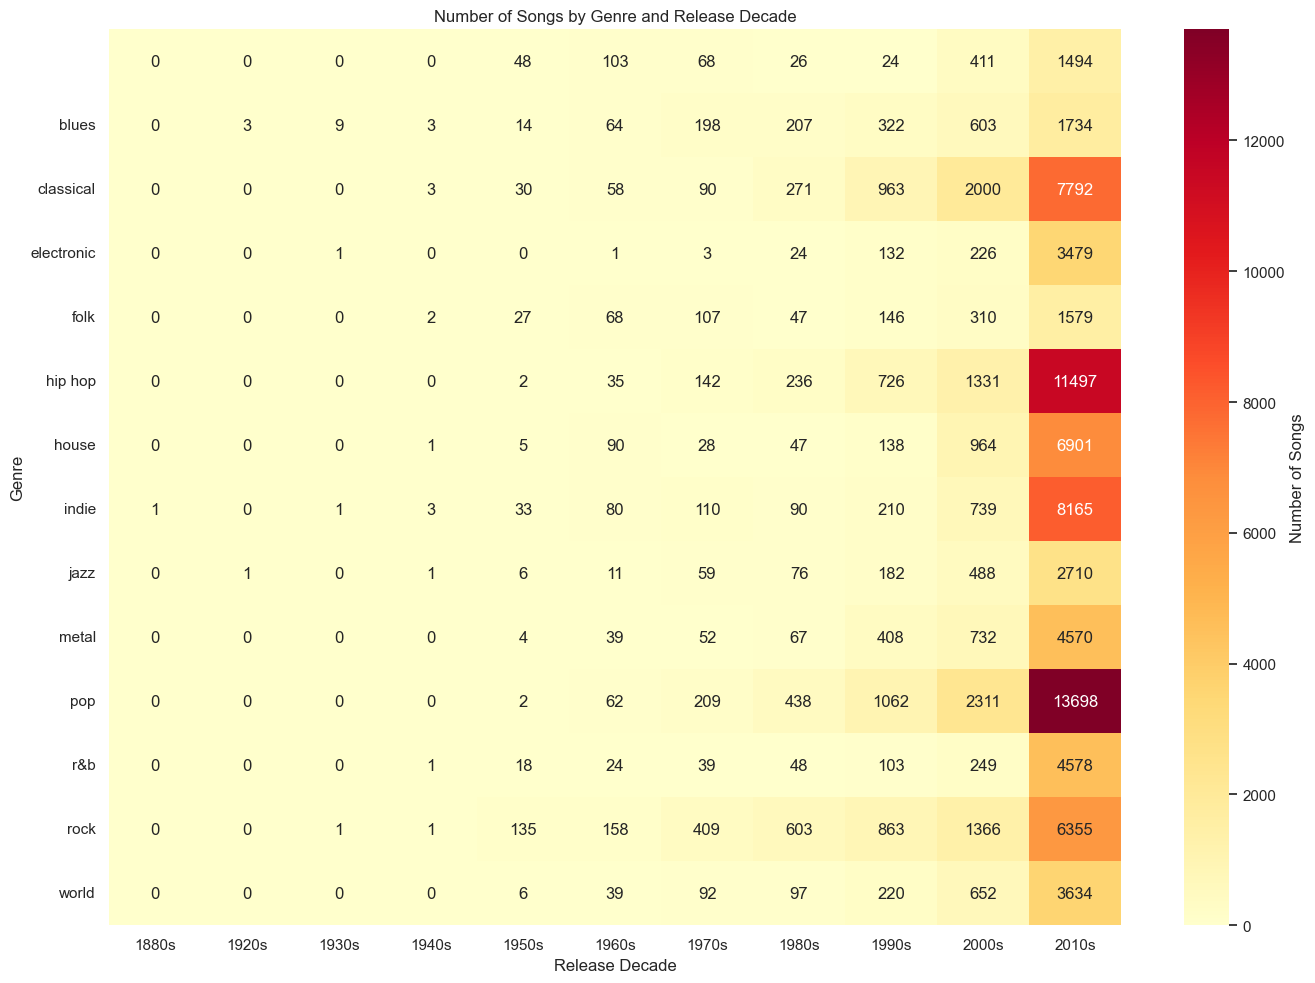

In [38]:
# Extract decade from release_date and count songs per decade and genre
df_tracks['release_decade'] = (df_tracks['release_date'].str[:4].astype(int) // 10 * 10).astype(str) + 's'

# Display songs count by genre and decade
decade_genre_counts = df_tracks.groupby(['artist_primary_genre_broad', 'release_decade']).size().unstack(fill_value=0)
display(decade_genre_counts)

# Optional: visualize as heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(decade_genre_counts, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Number of Songs'})
plt.title('Number of Songs by Genre and Release Decade')
plt.xlabel('Release Decade')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

In [39]:
df_tracks = df_tracks[df_tracks['is_podcast'] == 'no']
# output the number of observations for each genre in artist_primary_genre_broad
df_tracks.groupby('artist_primary_genre_broad').size()

artist_primary_genre_broad
blues          3133
classical     10451
electronic     3820
folk           2222
hip hop       13745
house          5333
indie          9228
jazz           3477
metal          5847
pop           17648
r&b            5005
rock           9169
world          4207
dtype: int64

We eliminate the podcast labelled tracks and ensure that all remaining tracks have a genre attribution.

## Stage 1: closest songs based on audio features

In [40]:
audio_feature_cols = [
    "acousticness",
    "danceability",
    "energy",
    "instrumentalness",
    "key",
    "liveness",
    "loudness",
    "mode",
    "speechiness",
    "tempo",
    "time_signature",
    "valence",
]

df_audio_features = (
    df_features[df_features["track_id"].isin(df_tracks["track_id"])]
    .set_index("track_id")[audio_feature_cols]
)

audio_scaler = StandardScaler()
X_audio = audio_scaler.fit_transform(df_audio_features)

knn_audio = NearestNeighbors(
    n_neighbors=min(20, len(df_audio_features)), metric="euclidean"
)
knn_audio.fit(X_audio)


def recommend_audio_neighbors(liked_track_ids, n_neighbors=20):
    if isinstance(liked_track_ids, (str, int)):
        liked_track_ids = [liked_track_ids]

    liked_track_ids = list(dict.fromkeys(liked_track_ids))
    missing = [tid for tid in liked_track_ids if tid not in df_audio_features.index]
    if missing:
        raise ValueError(f"Track ids not found in audio feature matrix: {missing}")

    liked_vectors = df_audio_features.loc[liked_track_ids].values
    centroid = liked_vectors.mean(axis=0).reshape(1, -1)
    scaled_centroid = audio_scaler.transform(centroid)

    query_k = min(
        len(df_audio_features),
        n_neighbors + len(liked_track_ids) + 50,
    )
    distances, indices = knn_audio.kneighbors(scaled_centroid, n_neighbors=query_k)

    neighbor_ids = df_audio_features.index[indices[0]]
    recommendations = pd.DataFrame(
        {"track_id": neighbor_ids, "distance": distances[0]}
    )

    liked_meta = df_tracks.set_index("track_id").loc[liked_track_ids]
    liked_artists = set(liked_meta["artists_id"])
    liked_albums = set(liked_meta["album_id"])

    recommendations = recommendations[~recommendations["track_id"].isin(liked_track_ids)]
    recommendations = recommendations.merge(
        df_tracks[["track_id", "artist_name", "artists_id", "album_id", "track_name", "artist_primary_genre_broad"]],
        on="track_id",
        how="left",
    )
    recommendations = recommendations[
        ~recommendations["artists_id"].isin(liked_artists)
        & ~recommendations["album_id"].isin(liked_albums)
    ]
    recommendations = recommendations.sort_values("distance").head(n_neighbors)

    return recommendations.reset_index(drop=True)


# Example
# recommend_audio_neighbors("5qljLQuKnNJf4F4vfxQB0V")

In [41]:

df_tracks[df_tracks["track_id"] == "5qljLQuKnNJf4F4vfxQB0V"][["track_name", "artist_name", "artist_primary_genre_broad"]]

,track_name,artist_name,artist_primary_genre_broad
0,Blood,Jesse Markin,indie


In [42]:
recommend_audio_neighbors("5qljLQuKnNJf4F4vfxQB0V")

,track_id,distance,artist_name,artists_id,album_id,track_name,artist_primary_genre_broad
0,2RbDFTlqdIdiZwO4GaTxi2,0.499200,kwassa,7hu7hjmIPOtU1S3D8zfBlw,1KM3bY05AzXEZr9TxwrKYF,moonwalking,indie
1,5QAFIgI6Mw9O8rb4liSfn6,0.506290,Margo Price,09yvLritEUxHrzx5TlFvbl,4tqSI5PSAH4qTljjD2MtKT,Most Likely You Go Your Way - Recorded at Soun...,world
2,1HnTINBSTfPo7F47hUs98J,0.550945,Aziz Maraka,2qi698G7BphxwdPUbQgZMU,5FCww0KdMiP4lKUzm4wEXY,Waggif,indie
3,6yDdry6QL3Zt3YS6QCtjKv,0.568639,Draco Rosa,4Vo7jk7sjpIFMk14dedex5,46P6LmowADoLY8T63o8a9S,Paraíso Prometido (Hay Que Llegar),rock
4,0ZvVoLABZzLWMbbn2a7uNy,0.670286,Lizz Görgl,0a5wU2GRrEOt9ewgb73riL,3O7FpHLgJjCrPHjmB45aCG,Bleib kurz stehn - Radio Edit,pop
5,654FxY36y0lK5BNEnQ0Bg4,0.673096,Ezra Jordan,1BM9iiJaq21vJlIwXsacEz,3i2qOSlKtxsQItzD3nH9vq,Lonely Now,r&b
6,1UEraN1dxpAjEQwqrgYaYf,0.687349,The Dø,2mcNCn1qbZUQ3J9KHapUxj,6PKWvfGLD69MNZKNJ5BP2n,On my shoulders,pop
7,7Hx6Lh9AZqkwK8LRfs6cL7,0.693558,Mondo Rock,0f7ChwXkRvmj2ViLbEQwYK,4Iu6eJb8nC0kUpTv5KZLnp,Come Said The Boy - Digitally Remastered,rock
8,1pGUl6SIkUG2eOAOwMN82W,0.701211,The Hillbilly Moon Explosion,2osRW41mzIig6TuqQeNsJR,5H0lRv5wf1n2d27g5whpBS,My Love for Evermore,rock
9,0xttqqTj7ZAGyVkfOYxQ4F,0.708457,Anirudh Ravichander,4zCH9qm4R2DADamUHMCa6O,3KxiTZwnVuot6XVWRqh4PZ,Nee Paartha Vizhigal - The Touch of Love,pop


## Test 1 Stage 1: genre consistency

To test the first stage of the pipeline, we input a simulated user session of 3 songs from the same genre. Then we calculate the 20 closest neighbors based on audio features and see how many of them are the same genre as the 3 liked songs in the user session.

In [43]:
test_set_2 = pd.read_csv(project_root / 'data' / 'test_sets' / 'test_genre_consistency.csv')
test_set_2.head()

,genre,seed_track_id_1,seed_track_id_2,seed_track_id_3
0,blues,7FJOfe35vaoRTyEkmyS5IP,0GqJRiWrTckISZVSFcgetc,1zGoa49cTiEJTIHtHmBdpG
1,blues,1pyKmZRflwwY85QnNcRXgv,5icCvoEvbKrSEO5HGPQbnG,0T4YRO7HV3ETSpIzHWJkNK
2,blues,6z7GYFQcNUkqjEOBWktpb5,3cGMK5oIwTvy4IZNVtWSxc,5VMg1UvquJtANDhn42p2ML
3,blues,75KB6JbAlkQ5J9MIWkIq65,5zhgJUGxCvOd8K7qn3BrY8,7CRJV0qUMAxftqySiPazpK
4,blues,6aWiGv6hPG0o3ri7QHNs8t,10V1dKQyQlL9nI7KpPPeBp,0KhMV9PmnLODalYHgp0MoC


In [44]:

def evaluate_genre_consistency(test_df, n_neighbors=20):
    rows = []
    for _, r in test_df.iterrows():
        genre = r["genre"]
        seeds = [r["seed_track_id_1"], r["seed_track_id_2"], r["seed_track_id_3"]]
        try:
            recs = recommend_audio_neighbors(seeds, n_neighbors=n_neighbors)
            n_same = int((recs["artist_primary_genre_broad"] == genre).sum())
            pct_same = n_same / len(recs) if len(recs) > 0 else np.nan
            rows.append({"genre": genre, "seeds": seeds, "n_same_genre": n_same, "pct_same_genre": pct_same})
        except ValueError as e:
            rows.append({"genre": genre, "seeds": seeds, "n_same_genre": np.nan, "pct_same_genre": np.nan, "error": str(e)})
    return pd.DataFrame(rows)

results = evaluate_genre_consistency(test_set_2, n_neighbors=20)

# Show per-query counts and overall summary by genre
display(results.head(10))
summary_by_genre = results.groupby("genre", dropna=False).agg(
    queries=("seeds", "size"),
    mean_same_genre=("n_same_genre", "mean"),
    mean_pct_same_genre=("pct_same_genre", "mean"),
).reset_index()
display(summary_by_genre)

# Overall averages
print("Overall mean same-genre count:", results["n_same_genre"].mean())
print("Overall mean same-genre percentage:", results["pct_same_genre"].mean())

,genre,seeds,n_same_genre,pct_same_genre
0,blues,"[7FJOfe35vaoRTyEkmyS5IP, 0GqJRiWrTckISZVSFcget...",2,0.10
1,blues,"[1pyKmZRflwwY85QnNcRXgv, 5icCvoEvbKrSEO5HGPQbn...",2,0.10
2,blues,"[6z7GYFQcNUkqjEOBWktpb5, 3cGMK5oIwTvy4IZNVtWSx...",0,0.00
3,blues,"[75KB6JbAlkQ5J9MIWkIq65, 5zhgJUGxCvOd8K7qn3BrY...",1,0.05
4,blues,"[6aWiGv6hPG0o3ri7QHNs8t, 10V1dKQyQlL9nI7KpPPeB...",0,0.00
5,blues,"[6odQ73ETHoNcR20P2NR5wV, 3Ds44Sf36tCFKmkV1IDr8...",2,0.10
6,blues,"[4UluFGXeIzL3SGLrX7qwuy, 1VLLADzAWGr1IoeMPDLND...",1,0.05
7,blues,"[0T4YRO7HV3ETSpIzHWJkNK, 5wRKOOqeJVbjgb1DZK9ks...",0,0.00
8,blues,"[0u2CGItUO2jYEiFaXD7n5S, 1s7EqwR1IPlaQO7iXaRUC...",1,0.05
9,blues,"[3knwd2whi9QUViKgWCsixF, 0Uyl6ZCHXgiBW1EfEPjZj...",3,0.15


,genre,queries,mean_same_genre,mean_pct_same_genre
0,blues,20,1.15,0.0575
1,classical,20,5.40,0.2700
2,electronic,20,4.15,0.2075
3,folk,20,1.25,0.0625
4,hip hop,20,8.55,0.4275
5,house,20,6.15,0.3075
6,indie,20,3.80,0.1900
7,jazz,20,2.75,0.1375
8,metal,20,2.95,0.1475
9,pop,20,5.50,0.2750


Overall mean same-genre count: 3.957692307692308
Overall mean same-genre percentage: 0.1978846153846154


On average out of the 20 neighbors (excluding same artist and same album) there are 4 songs from the same genre. This is 20% of the neighbors being in the same genre.

In [45]:
# Count queries with no same-genre neighbors
no_genre_matches = (results["n_same_genre"] == 0).sum()
total_queries = len(results)
pct_no_matches = (no_genre_matches / total_queries) * 100

print(f"Queries with no same-genre neighbors: {no_genre_matches} out of {total_queries} ({pct_no_matches:.1f}%)")

# Breakdown by genre
no_matches_by_genre = results[results["n_same_genre"] == 0].groupby("genre").size()
print("\nBreakdown by genre:")
print(no_matches_by_genre)

Queries with no same-genre neighbors: 40 out of 260 (15.4%)

Breakdown by genre:
genre
blues         5
classical     1
electronic    2
folk          9
hip hop       1
house         4
indie         2
jazz          3
metal         5
pop           2
r&b           1
rock          1
world         4
dtype: int64


Overall in 260 queries there were 40 in which none of the neighbors were in the same gnere. This means that 15% of these queries had no same genre in the 20 recommendations.

## Testing with different audio features

Now that we have the baseline metrics, we train recommenders with one feature always left out to see which features are important and which ones introduce noise.

In [46]:
def evaluate_genre_consistency_with_recommender(test_df, recommend_fn, n_neighbors=20):
    rows = []
    for _, r in test_df.iterrows():
        genre = r["genre"]
        seeds = [r["seed_track_id_1"], r["seed_track_id_2"], r["seed_track_id_3"]]
        try:
            recs = recommend_fn(seeds, n_neighbors=n_neighbors)
            n_same = int((recs["artist_primary_genre_broad"] == genre).sum())
            pct_same = n_same / len(recs) if len(recs) > 0 else np.nan
            rows.append({"genre": genre, "n_same_genre": n_same, "pct_same_genre": pct_same})
        except ValueError as e:
            rows.append({"genre": genre, "n_same_genre": np.nan, "pct_same_genre": np.nan, "error": str(e)})
    return pd.DataFrame(rows)


baseline_metrics = {
    "left_out_feature": "none",
    "mean_same_genre": results["n_same_genre"].mean(),
    "mean_pct_same_genre": results["pct_same_genre"].mean(),
    "queries_no_same_genre": int((results["n_same_genre"] == 0).sum()),
    "pct_no_same_genre": (results["n_same_genre"] == 0).mean() * 100,
}

comparison_rows = [baseline_metrics]

for feature in audio_feature_cols:
    subset_cols = [c for c in audio_feature_cols if c != feature]
    df_subset = df_audio_features[subset_cols]

    scaler = StandardScaler()
    X_subset = scaler.fit_transform(df_subset)

    knn_subset = NearestNeighbors(n_neighbors=min(20, len(df_subset)), metric="euclidean")
    knn_subset.fit(X_subset)

    def recommend_subset(liked_track_ids, n_neighbors=20):
        if isinstance(liked_track_ids, (str, int)):
            liked_track_ids = [liked_track_ids]

        liked_track_ids = list(dict.fromkeys(liked_track_ids))
        missing = [tid for tid in liked_track_ids if tid not in df_subset.index]
        if missing:
            raise ValueError(f"Track ids not found in audio feature matrix: {missing}")

        liked_vectors = df_subset.loc[liked_track_ids].values
        centroid = liked_vectors.mean(axis=0).reshape(1, -1)
        scaled_centroid = scaler.transform(centroid)

        query_k = min(len(df_subset), n_neighbors + len(liked_track_ids) + 50)
        distances, indices = knn_subset.kneighbors(scaled_centroid, n_neighbors=query_k)

        neighbor_ids = df_subset.index[indices[0]]
        recommendations = pd.DataFrame({"track_id": neighbor_ids, "distance": distances[0]})

        liked_meta = df_tracks.set_index("track_id").loc[liked_track_ids]
        liked_artists = set(liked_meta["artists_id"])
        liked_albums = set(liked_meta["album_id"])

        recommendations = recommendations[~recommendations["track_id"].isin(liked_track_ids)]
        recommendations = recommendations.merge(
            df_tracks[["track_id", "artist_name", "artists_id", "album_id", "track_name", "artist_primary_genre_broad"]],
            on="track_id",
            how="left",
        )
        recommendations = recommendations[
            ~recommendations["artists_id"].isin(liked_artists)
            & ~recommendations["album_id"].isin(liked_albums)
        ]
        recommendations = recommendations.sort_values("distance").head(n_neighbors)

        return recommendations.reset_index(drop=True)

    subset_results = evaluate_genre_consistency_with_recommender(test_set_2, recommend_subset, n_neighbors=20)

    comparison_rows.append({
        "left_out_feature": feature,
        "mean_same_genre": subset_results["n_same_genre"].mean(),
        "mean_pct_same_genre": subset_results["pct_same_genre"].mean(),
        "queries_no_same_genre": int((subset_results["n_same_genre"] == 0).sum()),
        "pct_no_same_genre": (subset_results["n_same_genre"] == 0).mean() * 100,
    })

comparison = pd.DataFrame(comparison_rows)
comparison = comparison[
    ["left_out_feature", "mean_same_genre", "mean_pct_same_genre", "queries_no_same_genre", "pct_no_same_genre"]
].sort_values("pct_no_same_genre")

display(comparison)

,left_out_feature,mean_same_genre,mean_pct_same_genre,queries_no_same_genre,pct_no_same_genre
1,acousticness,3.865385,0.193269,33,12.692308
7,loudness,3.907692,0.195385,33,12.692308
12,valence,3.503846,0.175192,36,13.846154
3,energy,3.915385,0.195769,37,14.230769
9,speechiness,3.619231,0.180962,37,14.230769
6,liveness,3.765385,0.188269,39,15.000000
11,time_signature,3.980769,0.199038,39,15.000000
0,none,3.957692,0.197885,40,15.384615
10,tempo,3.642308,0.182115,40,15.384615
8,mode,3.865385,0.193269,41,15.769231


We see that underneat the none row (which represents the full model) there are the features that seem so important that leaving them out actually increases the number of queries that have no same genre recommendations. We now go ahead and fit a model on only those genres to see if they alone make a better model than the full model.

In [47]:
selected_feature_cols = [
     "danceability",
    "energy",
    "instrumentalness",
    "liveness",
    "key",
    "mode",
    "tempo",
    "valence"
]
df_subset_small = df_audio_features[selected_feature_cols]

scaler_subset = StandardScaler()
X_subset_small = scaler_subset.fit_transform(df_subset_small)

knn_subset_small = NearestNeighbors(
    n_neighbors=min(20, len(df_subset_small)), metric="euclidean"
)
knn_subset_small.fit(X_subset_small)


def recommend_tempo_mode(liked_track_ids, n_neighbors=20):
    if isinstance(liked_track_ids, (str, int)):
        liked_track_ids = [liked_track_ids]

    liked_track_ids = list(dict.fromkeys(liked_track_ids))
    missing = [tid for tid in liked_track_ids if tid not in df_subset_small.index]
    if missing:
        raise ValueError(f"Track ids not found in audio feature matrix: {missing}")

    liked_vectors = df_subset_small.loc[liked_track_ids].values
    centroid = liked_vectors.mean(axis=0).reshape(1, -1)
    scaled_centroid = scaler_subset.transform(centroid)

    query_k = min(len(df_subset_small), n_neighbors + len(liked_track_ids) + 50)
    distances, indices = knn_subset_small.kneighbors(scaled_centroid, n_neighbors=query_k)

    neighbor_ids = df_subset_small.index[indices[0]]
    recommendations = pd.DataFrame({"track_id": neighbor_ids, "distance": distances[0]})

    liked_meta = df_tracks.set_index("track_id").loc[liked_track_ids]
    liked_artists = set(liked_meta["artists_id"])
    liked_albums = set(liked_meta["album_id"])

    recommendations = recommendations[~recommendations["track_id"].isin(liked_track_ids)]
    recommendations = recommendations.merge(
        df_tracks[
            ["track_id", "artist_name", "artists_id", "album_id", "track_name", "artist_primary_genre_broad"]
        ],
        on="track_id",
        how="left",
    )
    recommendations = recommendations[
        ~recommendations["artists_id"].isin(liked_artists)
        & ~recommendations["album_id"].isin(liked_albums)
    ]
    return recommendations.sort_values("distance").head(n_neighbors).reset_index(drop=True)


subset_results = evaluate_genre_consistency_with_recommender(
    test_set_2, recommend_tempo_mode, n_neighbors=20
)

mean_same = subset_results["n_same_genre"].mean()
mean_pct_same = subset_results["pct_same_genre"].mean()
queries_no_same = int((subset_results["n_same_genre"] == 0).sum())
pct_no_same = (subset_results["n_same_genre"] == 0).mean() * 100

print("Selected features:", selected_feature_cols)
print("Mean same-genre count:", mean_same)
print("Mean same-genre percentage:", mean_pct_same)
print("Queries with no same-genre neighbors:", queries_no_same, f"({pct_no_same:.1f}%)")

Selected features: ['danceability', 'energy', 'instrumentalness', 'liveness', 'key', 'mode', 'tempo', 'valence']
Mean same-genre count: 3.4269230769230767
Mean same-genre percentage: 0.17134615384615384
Queries with no same-genre neighbors: 32 (12.3%)


By try and error we derived the final model for the first stage of the recommender. We managed to get down the number of queries with no same genre from 40 (15.4%) to 32 (12.3%) of the queries. The average number of same genres among the neighbors has fallen from 3.95 to 3.42 however this is less so important as we anyways only need to give one recommendation from the 20 neighbors.

In [48]:
import joblib
import pandas as pd

models_dir = project_root / "models"
models_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(scaler_subset, models_dir / "selected_audio_scaler.joblib")
joblib.dump(knn_subset_small, models_dir / "selected_audio_knn.joblib")
df_subset_small.to_pickle(models_dir / "selected_audio_features.pkl")

recommender_file = models_dir / "recommender.py"
recommender_file.write_text(
    """from pathlib import Path

import joblib
import pandas as pd


def load_recommender(models_dir=None):
    models_dir = Path(models_dir or Path(__file__).parent)
    scaler = joblib.load(models_dir / \"selected_audio_scaler.joblib\")
    knn = joblib.load(models_dir / \"selected_audio_knn.joblib\")
    feature_matrix = pd.read_pickle(models_dir / \"selected_audio_features.pkl\")
    return scaler, knn, feature_matrix


def recommend_selected_neighbors(
    liked_track_ids,
    df_tracks,
    df_selected_features=None,
    scaler=None,
    knn=None,
    models_dir=None,
    n_neighbors=20,
):
    if isinstance(liked_track_ids, (str, int)):
        liked_track_ids = [liked_track_ids]

    if scaler is None or knn is None or df_selected_features is None:
        scaler, knn, df_selected_features = load_recommender(models_dir=models_dir)

    liked_track_ids = list(dict.fromkeys(liked_track_ids))
    missing = [tid for tid in liked_track_ids if tid not in df_selected_features.index]
    if missing:
        raise ValueError(f\"Track ids not found in selected feature matrix: {missing}\")

    liked_vectors = df_selected_features.loc[liked_track_ids].values
    centroid = liked_vectors.mean(axis=0).reshape(1, -1)
    scaled_centroid = scaler.transform(centroid)

    query_k = min(len(df_selected_features), n_neighbors + len(liked_track_ids) + 50)
    distances, indices = knn.kneighbors(scaled_centroid, n_neighbors=query_k)

    neighbor_ids = df_selected_features.index[indices[0]]
    recommendations = pd.DataFrame({\"track_id\": neighbor_ids, \"distance\": distances[0]})

    liked_meta = df_tracks.set_index(\"track_id\").loc[liked_track_ids]
    liked_artists = set(liked_meta[\"artists_id\"])
    liked_albums = set(liked_meta[\"album_id\"])

    recommendations = recommendations[~recommendations[\"track_id\"].isin(liked_track_ids)]
    recommendations = recommendations.merge(
        df_tracks[
            [\"track_id\", \"artist_name\", \"artists_id\", \"album_id\", \"track_name\", \"artist_primary_genre_broad\"]
        ],
        on=\"track_id\",
        how=\"left\",
    )
    recommendations = recommendations[
        ~recommendations[\"artists_id\"].isin(liked_artists)
        & ~recommendations[\"album_id\"].isin(liked_albums)
    ]
    return recommendations.sort_values(\"distance\").head(n_neighbors).reset_index(drop=True)
"""
)

print(f"Saved selected model and recommender module to {models_dir}")

Saved selected model and recommender module to /Users/radakovic/Desktop/FH_DS/SS26/solution_eng/soe-spotify/models


## Stage 2: genre based elimination

Based on the 20 neighbors output from the first stage we pick the closest same genre song as the recommendation.

In [49]:
def select_same_genre_neighbor(neighbors_df, liked_track_ids, genre_col="artist_primary_genre_broad"):
    if isinstance(liked_track_ids, (str, int)):
        liked_track_ids = [liked_track_ids]

    liked_track_ids = list(dict.fromkeys(liked_track_ids))
    missing = [tid for tid in liked_track_ids if tid not in df_tracks["track_id"].values]
    if missing:
        raise ValueError(f"Track ids not found in df_tracks: {missing}")

    liked_meta = df_tracks.set_index("track_id").loc[liked_track_ids]
    liked_genres = set(
        liked_meta[genre_col]
        .dropna()
        .astype(str)
        .tolist()
    )

    if not liked_genres:
        raise ValueError(
            f"No genre values found for liked tracks in column '{genre_col}'."
        )

    same_genre_neighbors = neighbors_df[
        neighbors_df[genre_col].isin(liked_genres)
    ].copy()

    if not same_genre_neighbors.empty:
        return same_genre_neighbors.sort_values("distance").head(1).reset_index(drop=True)

    return neighbors_df.sort_values("distance").head(1).reset_index(drop=True)

Example of the pipeline from one song to the 20 neighbors and then the same genre recommendation.

In [50]:
song_id = "5qljLQuKnNJf4F4vfxQB0V"

neighbors = recommend_tempo_mode(song_id, n_neighbors=20)
final_recommendation = select_same_genre_neighbor(neighbors, song_id)

original_song_info = df_tracks[
    df_tracks["track_id"] == song_id
][["track_id", "track_name", "artist_name", "artist_primary_genre_broad"]]

print("Original song:")
display(original_song_info)

print("\n20 nearest neighbors:")
display(neighbors)

print("\nFinal recommendation:")
display(final_recommendation[["track_id", "track_name", "artist_name", "artist_primary_genre_broad", "distance"]])

Original song:


,track_id,track_name,artist_name,artist_primary_genre_broad
0,5qljLQuKnNJf4F4vfxQB0V,Blood,Jesse Markin,indie



20 nearest neighbors:


,track_id,distance,artist_name,artists_id,album_id,track_name,artist_primary_genre_broad
0,4FTfle9rvqdgFeyPA9EWRS,0.383301,Rayden,6G43BFwUJvFWbev3knhgEa,5sFgKb5iJQmqGV8oKlYpHs,Haz de luz,hip hop
1,5QAFIgI6Mw9O8rb4liSfn6,0.415331,Margo Price,09yvLritEUxHrzx5TlFvbl,4tqSI5PSAH4qTljjD2MtKT,Most Likely You Go Your Way - Recorded at Soun...,world
2,6yDdry6QL3Zt3YS6QCtjKv,0.435797,Draco Rosa,4Vo7jk7sjpIFMk14dedex5,46P6LmowADoLY8T63o8a9S,Paraíso Prometido (Hay Que Llegar),rock
3,3EIloISJJFMs88jSmvOSMa,0.443582,Skott,6J3RPKUwZlKMzh3vWa9wPc,5nwcMFsg6l1JJXmnHtrH0T,Stay Off My Mind,pop
4,6yM82PxMywRHehdoQgQT8p,0.459406,Bola Johnson,7CfyXrIeIEd05s0nEPvjW1,0oQKeXlY2O4QAP83DUn2n5,Lagos Sisi,hip hop
5,2RbDFTlqdIdiZwO4GaTxi2,0.470874,kwassa,7hu7hjmIPOtU1S3D8zfBlw,1KM3bY05AzXEZr9TxwrKYF,moonwalking,indie
6,4CZ2wKpcjgoQDxGMQNUdqb,0.473804,Maysa Daw,3oCd1GdkMu8peoq2r9ceI6,0aUGJkdUCaTmBqlB2gD3I0,Enough,pop
7,6ZZA5LtiMyhmo4jU3oldOZ,0.481592,kent,4KXp3xtaz1wWXnu5u34eVX,7jNwRyfpnImFDM9Y1QDNfz,Egoist,rock
8,2mVW3YWtFGaXeIckXb4L4D,0.502523,Nao,7aFTOGFDEqDtJUCziLVsVC,4YN6Zg6ANvwAdG2z8iV6Vu,Another Lifetime - Shareware Remix,r&b
9,198cVpefC0FRLSXpX2Wpts,0.505762,Tamer Hosny,4cGfgRmpFc9zgZMfuSXhqy,59Behg6SoGd5d4U4ljmZDg,Kabelteeny,pop



Final recommendation:


,track_id,track_name,artist_name,artist_primary_genre_broad,distance
0,2RbDFTlqdIdiZwO4GaTxi2,moonwalking,kwassa,indie,0.470874


## Test 2 Stage 2: fallback options

In [51]:
test_set_1 = pd.read_csv(project_root / 'data' / 'test_sets' / 'test_distance_like_dislike.csv')
test_set_1.head()

,seed_track_id,feedback_sequence
0,5tVmntyj8rlJaFNBiUoWSC,"[-1, 1, 1, 1, 1, 1, 1, -1, 1, 1]"
1,0If3UxapVCA0NUKgpJkpaj,"[-1, 1, -1, 1, 1, 1, -1, 1, 1, -1]"
2,6fh2YS29IrmW1yCHMlTDTM,"[-1, 1, -1, -1, 1, 1, -1, -1, -1, 1]"
3,5qzfsHAvFUWFChTxo9hEe6,"[1, -1, 1, -1, 1, -1, -1, -1, 1, -1]"
4,4E1jg7m6rq4ofqfoKQ16LN,"[-1, -1, -1, -1, 1, 1, -1, -1, -1, 1]"


We run 100 simulated user queries and see how many times the closest neighbors have no genre in the 20 clocest neighbor.

In [52]:
def run_simulated_user_query(test_df, recommend_fn, select_same_genre_fn):
    """
    Simulate user queries with feedback sequences.
    Track recommendations and fallback usage.
    """
    rows = []
    
    for _, row in test_df.iterrows():
        seed_track_id = row["seed_track_id"]
        feedback_sequence = eval(row["feedback_sequence"]) if isinstance(row["feedback_sequence"], str) else row["feedback_sequence"]
        
        liked_tracks = [seed_track_id]
        
        for feedback in feedback_sequence:
            try:
                # Get 20 neighbors based on liked tracks
                neighbors = recommend_fn(liked_tracks, n_neighbors=20)
                
                # Select recommendation using genre-based logic
                recommendation = select_same_genre_fn(neighbors, liked_tracks)
                
                # Check if fallback was used (no same genre in 20 neighbors)
                same_genre_neighbors = neighbors[
                    neighbors["artist_primary_genre_broad"].isin(
                        df_tracks.set_index("track_id").loc[liked_tracks, "artist_primary_genre_broad"].unique()
                    )
                ]
                used_fallback = len(same_genre_neighbors) == 0
                
                rec_track_id = recommendation["track_id"].values[0]
                
                rows.append({
                    "seed_track_id": seed_track_id,
                    "liked_tracks_count": len(liked_tracks),
                    "feedback": feedback,
                    "recommendation_track_id": rec_track_id,
                    "used_fallback": used_fallback,
                })
                
                # Update liked tracks based on feedback
                if feedback == 1:
                    if rec_track_id not in liked_tracks:
                        liked_tracks.append(rec_track_id)
                
            except Exception as e:
                rows.append({
                    "seed_track_id": seed_track_id,
                    "liked_tracks_count": len(liked_tracks),
                    "feedback": feedback,
                    "recommendation_track_id": None,
                    "used_fallback": None,
                    "error": str(e),
                })
    
    return pd.DataFrame(rows)


# Run simulation
simulation_results = run_simulated_user_query(test_set_1, recommend_tempo_mode, select_same_genre_neighbor)

# Calculate fallback statistics
fallback_count = simulation_results["used_fallback"].sum()
total_recommendations = len(simulation_results)
fallback_percentage = (fallback_count / total_recommendations) * 100

print(f"Total recommendations made: {total_recommendations}")
print(f"Fallback used (no same genre): {int(fallback_count)} times")
print(f"Fallback percentage: {fallback_percentage:.1f}%")
print("\nFirst 10 results:")
display(simulation_results.head(10))

Total recommendations made: 2000
Fallback used (no same genre): 260 times
Fallback percentage: 13.0%

First 10 results:


,seed_track_id,liked_tracks_count,feedback,recommendation_track_id,used_fallback
0,5tVmntyj8rlJaFNBiUoWSC,1,-1,1vr8QWVT3ibyaFdqQxiMwI,False
1,5tVmntyj8rlJaFNBiUoWSC,1,1,1vr8QWVT3ibyaFdqQxiMwI,False
2,5tVmntyj8rlJaFNBiUoWSC,2,1,5Gbhq0dW55m4hgZtoyOb9e,False
3,5tVmntyj8rlJaFNBiUoWSC,3,1,3ojuKgQ4IMf7zpxyHEKTwO,False
4,5tVmntyj8rlJaFNBiUoWSC,4,1,0uLCRADshP7njj8Eqw6Jxv,False
5,5tVmntyj8rlJaFNBiUoWSC,5,1,4Rptvwrq8cgjOlYGVgeWVv,False
6,5tVmntyj8rlJaFNBiUoWSC,6,1,542euFCbVFpO9hReNoFxrS,False
7,5tVmntyj8rlJaFNBiUoWSC,7,-1,340XDhzmoHiXK9sVzFz8eh,False
8,5tVmntyj8rlJaFNBiUoWSC,7,1,340XDhzmoHiXK9sVzFz8eh,False
9,5tVmntyj8rlJaFNBiUoWSC,8,1,7t5JQfqAYOgrS9iccB8dy5,False


The second stage of the pipeline (elimination based on genre) could not be carried out 13% of the times due to the lack of same genres among the 20 neighbors. 

In [53]:
stage2_module = models_dir / "genre_selection.py"

stage2_module.write_text(
    """def select_same_genre_neighbor(neighbors_df, liked_track_ids, df_tracks, genre_col='artist_primary_genre_broad'):
    if isinstance(liked_track_ids, (str, int)):
        liked_track_ids = [liked_track_ids]

    liked_track_ids = list(dict.fromkeys(liked_track_ids))
    missing = [tid for tid in liked_track_ids if tid not in df_tracks['track_id'].values]
    if missing:
        raise ValueError(f'Track ids not found in df_tracks: {missing}')

    liked_meta = df_tracks.set_index('track_id').loc[liked_track_ids]
    liked_genres = set(
        liked_meta[genre_col]
        .dropna()
        .astype(str)
        .tolist()
    )

    if not liked_genres:
        raise ValueError(
            f\"No genre values found for liked tracks in column '{genre_col}'.\"
        )

    same_genre_neighbors = neighbors_df[
        neighbors_df[genre_col].isin(liked_genres)
    ].copy()

    if not same_genre_neighbors.empty:
        return same_genre_neighbors.sort_values('distance').head(1).reset_index(drop=True)

    return neighbors_df.sort_values('distance').head(1).reset_index(drop=True)
"""
)

print(f"Saved stage 2 genre elimination module to {stage2_module}")

Saved stage 2 genre elimination module to /Users/radakovic/Desktop/FH_DS/SS26/solution_eng/soe-spotify/models/genre_selection.py


## Visualization

In [65]:
dua_lipa_songs = df_tracks[df_tracks['artist_name'] == 'Madonna'][['track_id', 'track_name', 'artist_name', 'artist_primary_genre_broad', 'release_date']].sort_values('release_date')
display(dua_lipa_songs)

,track_id,track_name,artist_name,artist_primary_genre_broad,release_date
11714,3ibAzRj9JnowdoLkyllk3n,Holiday,Madonna,pop,1983-07-27
12185,3E79grOLqLpNER2JT2TtL0,"Burning Up - 12"" Version",Madonna,pop,1983-07-27
12960,2hWI9GNr3kBrxZ7Mphho4Q,Lucky Star,Madonna,pop,1983-07-27
19854,7arHM2KZ0KzIZXFVDRGClI,Holiday,Madonna,pop,1983-07-27
80671,1ZPlNanZsJSPK5h9YZZFbZ,Like a Virgin,Madonna,pop,1984-11-12
94493,7bkyXSi4GtVfD7itZRUR3e,Material Girl,Madonna,pop,1984-11-12
23412,1jaVdF0FSPTWi8E4MWiLPR,La Isla Bonita - Extended Remix,Madonna,pop,1986-06-30
25618,095MMFhB9qxPx2VsmvjnUs,Live to Tell,Madonna,pop,1986-06-30
43922,6r8k1vznHrzlEKYxL4dZEe,La Isla Bonita,Madonna,pop,1986-06-30
81307,6A8OnjnpShshNpcqWtZRjr,Papa Don't Preach,Madonna,pop,1986-06-30


In [66]:
import sys
import importlib
import joblib
import pandas as pd
from pathlib import Path

# Resolve the repository root reliably from the notebook runtime
project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

models_dir = project_root / "models"

# Import the recommender module from the models folder
import models.recommender as recommender_module
importlib.reload(recommender_module)

load_recommender = recommender_module.load_recommender
recommend_selected_neighbors = recommender_module.recommend_selected_neighbors
from models.genre_selection import select_same_genre_neighbor

# Load the saved scaler, KNN model, and feature matrix via the recommender module
scaler, knn, df_selected_features = load_recommender(models_dir=models_dir)

# Generate recommendation for the song
liked_track_id = "3ibAzRj9JnowdoLkyllk3n"

# Stage 1: Get 20 nearest neighbors based on audio features
neighbors = recommend_selected_neighbors(
    liked_track_id,
    df_tracks,
    df_selected_features=df_selected_features,
    scaler=scaler,
    knn=knn,
    n_neighbors=20,
)

# Stage 2: Select the closest same-genre neighbor
final_recommendation = select_same_genre_neighbor(neighbors, liked_track_id, df_tracks)

# Display results
print("Original song:")
display(df_tracks[df_tracks["track_id"] == liked_track_id][["track_id", "track_name", "artist_name", "artist_primary_genre_broad"]])

print("\nFinal recommendation:")
display(final_recommendation[["track_id", "track_name", "artist_name", "artist_primary_genre_broad", "distance"]])

Original song:


,track_id,track_name,artist_name,artist_primary_genre_broad
11714,3ibAzRj9JnowdoLkyllk3n,Holiday,Madonna,pop



Final recommendation:


,track_id,track_name,artist_name,artist_primary_genre_broad,distance
0,5UD3gbtQ4KJ2CRQp9byOwQ,High On Me,Guy Sebastian,pop,0.368195


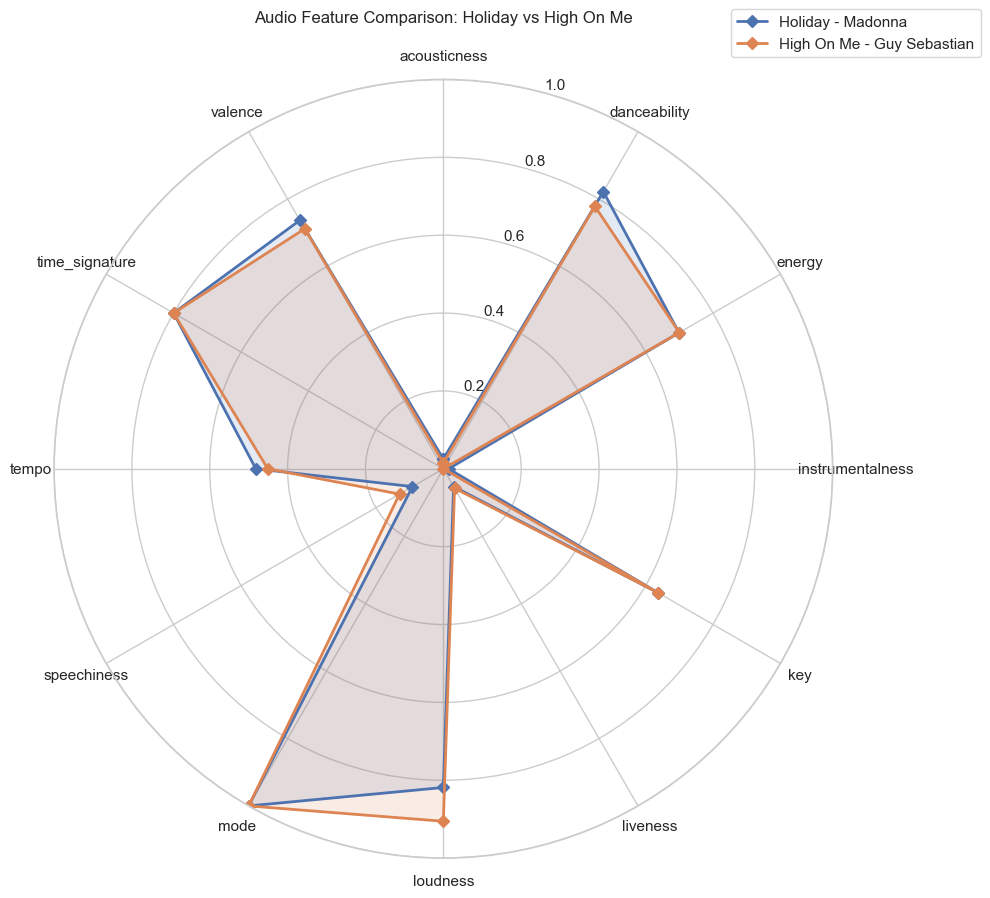

In [68]:
song_ids = [
    liked_track_id,
    final_recommendation.loc[0, "track_id"],
]

song_labels = df_tracks.set_index("track_id").loc[song_ids, "track_name"].to_dict()
song_labels = {
    song_ids[0]: f"Holiday - Madonna",
    song_ids[1]: f"High On Me - Guy Sebastian",
}

song_features = df_audio_features.loc[song_ids, audio_feature_cols]

feature_ranges = df_audio_features[audio_feature_cols].agg(["min", "max"])
feature_ranges = feature_ranges.transpose()

normed = song_features.copy()
for feature in audio_feature_cols:
    min_val = feature_ranges.loc[feature, "min"]
    max_val = feature_ranges.loc[feature, "max"]
    if max_val > min_val:
        normed[feature] = (normed[feature] - min_val) / (max_val - min_val)
    else:
        normed[feature] = 0.5

labels = audio_feature_cols
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={"projection": "polar"})

for track_id, values in normed.iterrows():
    vals = values.tolist()
    vals += vals[:1]
    ax.plot(
        angles,
        vals,
        label=song_labels.get(track_id, track_id),
        marker="D",
        linewidth=2,
    )
    ax.fill(angles, vals, alpha=0.15)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_rlabel_position(180 / len(labels))
ax.set_ylim(0, 1)
ax.set_title("Audio Feature Comparison: Holiday vs High On Me", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))

plt.tight_layout()
plt.show()

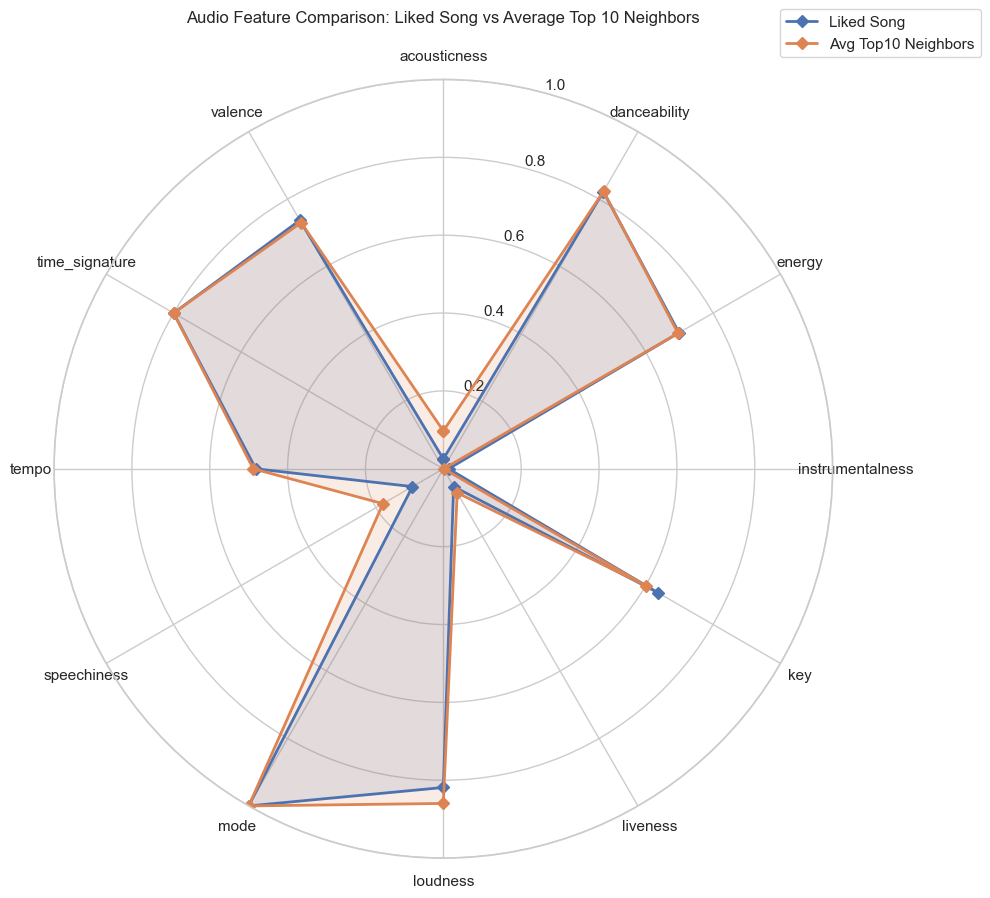

In [69]:
neighbors_10 = neighbors.head(10).copy()

liked_feature_vector = df_audio_features.loc[liked_track_id, audio_feature_cols]
avg_neighbor_vector = (
    df_audio_features.loc[neighbors_10["track_id"], audio_feature_cols]
    .mean(axis=0)
)

feature_ranges = df_audio_features[audio_feature_cols].agg(["min", "max"]).transpose()

def normalize_vector(series):
    series = series.copy()
    for feature in audio_feature_cols:
        min_val = feature_ranges.loc[feature, "min"]
        max_val = feature_ranges.loc[feature, "max"]
        if max_val > min_val:
            series[feature] = (series[feature] - min_val) / (max_val - min_val)
        else:
            series[feature] = 0.5
    return series

liked_normed = normalize_vector(liked_feature_vector)
avg_neighbors_normed = normalize_vector(avg_neighbor_vector)

chart_data = pd.DataFrame(
    [liked_normed, avg_neighbors_normed],
    index=["liked_song", "avg_top10_neighbors"],
)

labels = audio_feature_cols
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={"projection": "polar"})

for label, row in chart_data.iterrows():
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, label=label.replace("_", " ").title(), marker="D", linewidth=2)
    ax.fill(angles, values, alpha=0.15)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_rlabel_position(180 / len(labels))
ax.set_ylim(0, 1)
ax.set_title("Audio Feature Comparison: Liked Song vs Average Top 10 Neighbors", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))

plt.tight_layout()
plt.show()